# Telecom Customer Churn Analysis

## 03: Bivariate Analysis and Churn Drivers

### Objective

This notebook investigates relationships between customer characteristics, service usage, billing behavior, and customer churn.

The analysis focuses on:

- Examining relationships between demographic characteristics and customer behavior
- Exploring how customer tenure relates to billing, revenue, and service usage
- Investigating how service subscriptions, internet types, offers, and contracts relate to monthly charges
- Comparing customer characteristics and behaviors across different customer statuses
- Identifying patterns associated with churn that warrant further investigation

This builds on the univariate analysis to develop a deeper understanding of how customer characteristics and behaviors relate to one another, while identifying potential churn drivers for further analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load cleaned dataset from first notebook
churn_df = pd.read_parquet('../data/processed/telecom_customer_churn_clean.parquet')

In [4]:
# Set visualization settings
sns.set_theme(style='white', 
              context='notebook', 
              palette='deep')

plt.rcParams['figure.figsize'] = (5, 3)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 16
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelpad'] = 6
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### Customer Profile and Behavior

##### Age and Internet
- Are older customers less likely to have internet service than young customers?
- Do older customers use less data than younger customers?

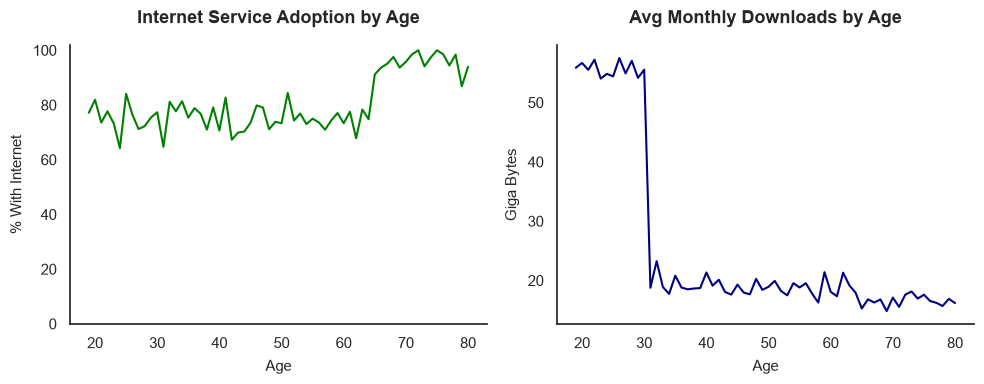

In [8]:
internet_customers = churn_df[churn_df['Internet Service'] == True]

# Calculate Download Consumption by Age
gb_by_age = (
    internet_customers.groupby('Age')['Avg Monthly GB Download'].mean()
)

# Calculate Internet Service adoption rate by Age
internet_by_age = churn_df.groupby('Age')['Internet Service'].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(
    internet_by_age.index,
    internet_by_age.values,
    color='green'
)

ax1.set_title('Internet Service Adoption by Age')
ax1.set_ylabel('% With Internet')
ax1.set_xlabel('Age')
ax1.set_ylim(bottom=0)

ax2.plot(
    gb_by_age.index,
    gb_by_age.values,
    color='navy'
)

ax2.set_title('Avg Monthly Downloads by Age')
ax2.set_ylabel('Giga Bytes')
ax2.set_xlabel('Age')
plt.tight_layout();

Customers aged 65 and older have an internet service adoption rate of approximately 90–100%, compared with roughly 65–85% among younger customers. Among customers with internet service, those aged 30 and below download an average of approximately 50–55 GB per month. Average usage drops sharply around age 31 and remains at roughly 15–20 GB per month among older customers.

**Overall, even though older customers are more likely to have internet service, they use less data on average than younger subscribers.**

##### Number of Dependents and Services, Data Usage
- Are customers with dependents more likely to subscribe to core services?
- Are customers with dependents more likely to subscribe to streaming services?
- Do customers with dependents download more data per month on average?

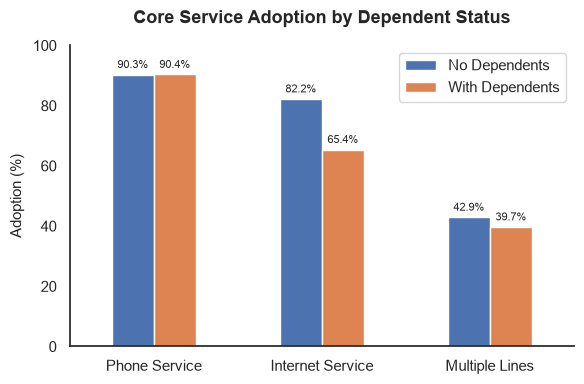

In [186]:
phone_service_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Phone Service'].mean() * 100
internet_service_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Internet Service'].mean() * 100
multiple_lines_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Multiple Lines'].mean() * 100

core_service_adoption = pd.DataFrame(
    {
        'Phone Service': phone_service_by_dependents,
        'Internet Service': internet_service_by_dependents,
        'Multiple Lines': multiple_lines_by_dependents
    }
).T

ax = core_service_adoption.plot.bar(
    figsize=(6, 4),
    rot=0
    )

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=8
    )
    
ax.set_title('Core Service Adoption by Dependent Status')
ax.set_ylabel('Adoption (%)')
ax.set_ylim(top=100)
ax.legend(['No Dependents', 'With Dependents'])
plt.tight_layout();

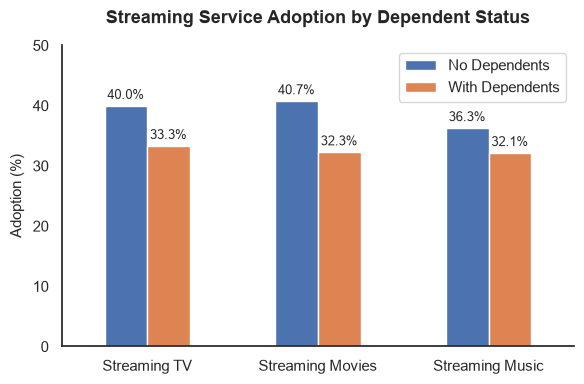

In [188]:
streaming_tv_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Streaming TV'].mean() * 100
streaming_movies_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Streaming Movies'].mean() * 100
streaming_music_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Streaming Music'].mean() * 100

streaming_service_adoption = pd.DataFrame(
    {
        'Streaming TV': streaming_tv_by_dependents,
        'Streaming Movies': streaming_movies_by_dependents,
        'Streaming Music': streaming_music_by_dependents
    }
).T

ax = streaming_service_adoption.plot.bar(
    figsize=(6, 4),
    rot=0
    )

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=9
    )

ax.set_title('Streaming Service Adoption by Dependent Status')
ax.set_ylabel('Adoption (%)')
ax.set_ylim(top=50)
ax.legend(['No Dependents', 'With Dependents'])
plt.tight_layout();


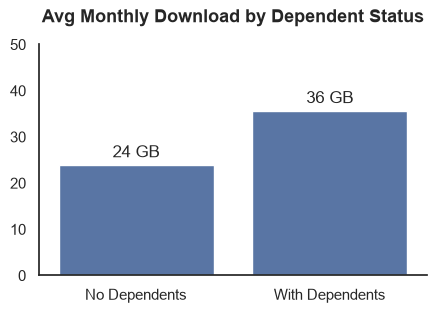

In [189]:
internet_customers = churn_df[churn_df['Internet Service']]
monthly_download_by_dependents = internet_customers.groupby(internet_customers['Number of Dependents'] > 0)['Avg Monthly GB Download'].mean()

ax = sns.barplot(
    x=monthly_download_by_dependents.index,
    y=monthly_download_by_dependents.values
)

ax.bar_label(ax.containers[0], 
             fmt='%.0f GB', 
             padding=3)

plt.title('Avg Monthly Download by Dependent Status')
plt.ylim(top=50)
plt.xlabel('')
plt.xticks([0, 1], ['No Dependents', 'With Dependents']);

Customers without dependents have an internet service adoption rate of 16.8 percentage points higher than customers with dependents. Phone service and multiple-line adoption differ by just 0.1 and 3.2 percentage points, respectively.

Customers without dependents also have higher adoption rates for all three streaming services—TV, movies, and music—by approximately 4–7 percentage points.

However, among customers with internet service, those with at least one dependent download approximately 12 GB more data per month on average than those without dependents.


##### Marital Status and Referral Behavior
Do married customers make more referrals than unmarried customers?

In [100]:
churn_df.groupby('Married')['Number of Referrals'].agg(['sum', 'mean'])

,sum,mean
Married,,
False,0,0.0
True,13747,4.040858


None of the unmarried customers recorded any referrals in this dataset. All recorded referrals came from married customers.

##### Gender and Avg Monthly Data Usage
Do male and female internet subscribers use different amounts of data on average?

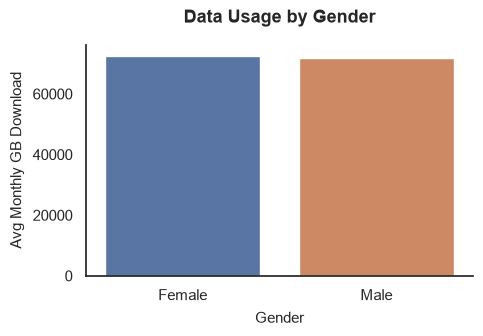

In [19]:
gb_by_gender = internet_customers.groupby('Gender')['Avg Monthly GB Download'].sum().reset_index()

sns.barplot(
    gb_by_gender,
    x='Gender',
    y='Avg Monthly GB Download',
    hue='Gender',
    dodge=False
)

plt.title('Data Usage by Gender');

There is no significant difference between the monthly data usage of Male and Female customers.

##### Gender and Other Services
- Does adoption of streaming services differ by gender?
- Does adoption of additional services differ by gender?

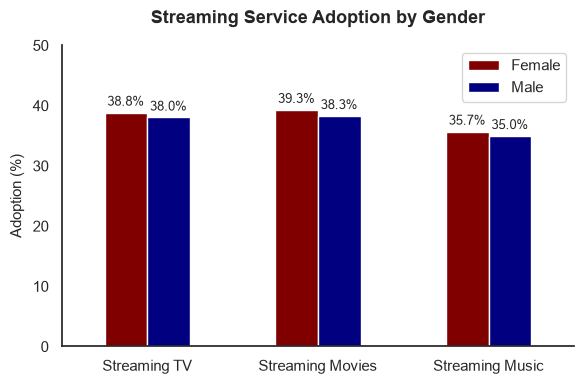

In [21]:
streaming_tv_by_gender = churn_df.groupby('Gender')['Streaming TV'].mean() * 100

streaming_movies_by_gender = churn_df.groupby('Gender')['Streaming Movies'].mean() * 100

streaming_music_by_gender = churn_df.groupby('Gender')['Streaming Music'].mean() * 100

streaming_service_adoption = pd.DataFrame(
    {
        'Streaming TV': streaming_tv_by_gender,
        'Streaming Movies': streaming_movies_by_gender,
        'Streaming Music': streaming_music_by_gender
    }
).T

ax = streaming_service_adoption.plot.bar(
    figsize=(6, 4),
    rot=0,
    color=['maroon', 'navy']
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=9
    )

ax.set_title('Streaming Service Adoption by Gender')
ax.set_ylabel('Adoption (%)')
ax.set_ylim(top=50)
ax.legend(['Female', 'Male'])

plt.tight_layout();

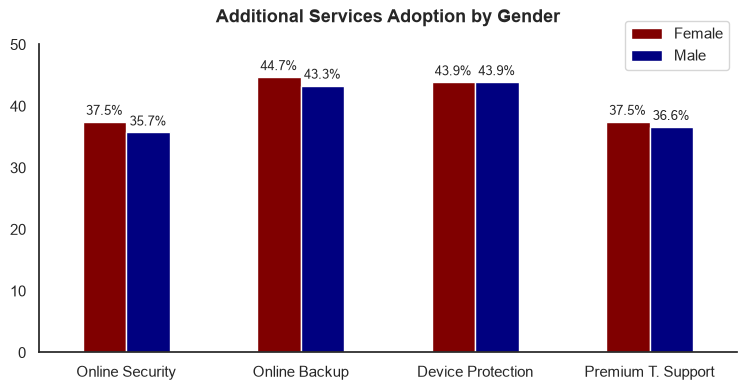

In [224]:
online_security_by_gender = internet_customers.groupby('Gender')['Online Security'].mean() * 100
online_backup_by_gender = internet_customers.groupby('Gender')['Online Backup'].mean() * 100
device_protection_plan_by_gender = internet_customers.groupby('Gender')['Device Protection Plan'].mean() * 100
premium_tech_support_by_gender = internet_customers.groupby('Gender')['Premium Tech Support'].mean() * 100

additional_services_adoption = pd.DataFrame(
    {
        'Online Security': online_security_by_gender,
        'Online Backup': online_backup_by_gender,
        'Device Protection Plan': device_protection_plan_by_gender,
        'Premium Tech Support': premium_tech_support_by_gender
    }
).T

ax = additional_services_adoption.plot.bar(
    rot=0,
    figsize=(9, 4),
    color=['maroon', 'navy']
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=9
    )

ax.set_title('Additional Services Adoption by Gender')
ax.set_ylim(top=50)
ax.legend(bbox_to_anchor=(1, 1.1))
ax.set_xticks([0, 1, 2, 3], 
              ['Online Security', 'Online Backup', 'Device Protection', 'Premium T. Support'])
plt.tight_layout;

Among customers with internet service, adoption of streaming and additional services shows little variation by gender, with differences of less than 2 percentage points across all eight services.

### Tenure and Customer Value



##### Tenure and Revenue
- Does total revenue increase with customer tenure?
- Does average monthly revenue vary with customer tenure?

Pearson Correlation
Customer Tenure vs. Total Revenue: 0.85
Customer Tenure vs. Avg Monthly Revenue: 0.20


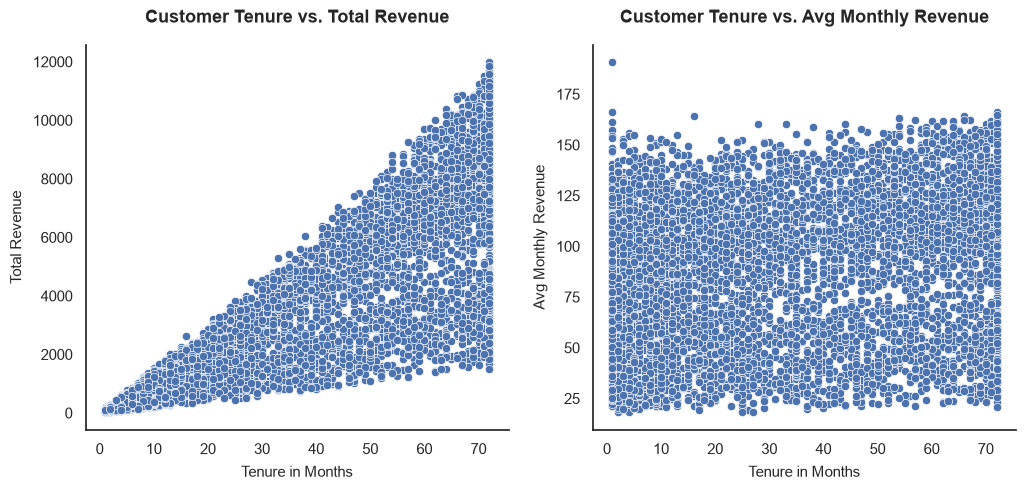

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1 = sns.scatterplot(
    x=churn_df['Tenure in Months'],
    y=churn_df['Total Revenue'],
    ax=ax1
)

ax1.set_title('Customer Tenure vs. Total Revenue')

avg_monthly_revenue = churn_df['Total Revenue'] / churn_df['Tenure in Months']
ax2 = sns.scatterplot(
    churn_df,
    x='Tenure in Months',
    y=avg_monthly_revenue.values,
    ax=ax2
)

ax2.set_title('Customer Tenure vs. Avg Monthly Revenue')
ax2.set_ylabel('Avg Monthly Revenue')

print('Pearson Correlation')
print(f"Customer Tenure vs. Total Revenue: {churn_df['Tenure in Months'].corr(churn_df['Total Revenue']):.2f}")
print(f"Customer Tenure vs. Avg Monthly Revenue: {churn_df['Tenure in Months'].corr(avg_monthly_revenue):.2f}")


Customer tenure and total revenue have a strong positive correlation (r = 0.85). Total revenue generally increases with tenure as revenue accumulates over time, but its variability also increases, with longer-tenured customers showing a wider range of total revenue. Meanwhile, average monthly revenue shows no clear pattern with tenure and has only a weak positive correlation (r = 0.20).  

##### Tenure and Charges
- Do longer-tenured customers tend to have higher monthly charges?
- Do total charges increase with customer tenure?

Pearson Correlation
Customer Tenure vs. Total Charges: 0.83
Customer Tenure vs. Monthly Charge: 0.24


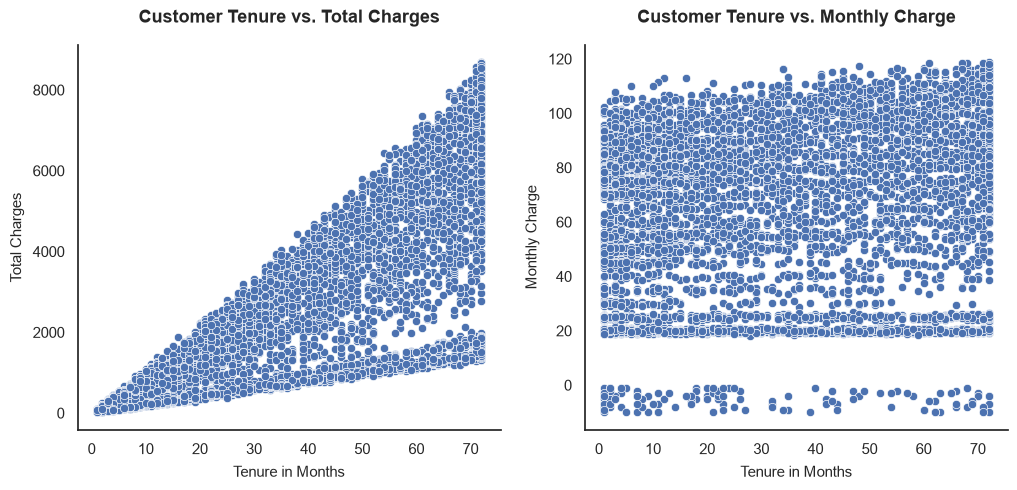

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1 = sns.scatterplot(
    churn_df,
    x='Tenure in Months',
    y='Total Charges',
    ax=ax1
)

ax1.set_title('Customer Tenure vs. Total Charges')

ax2 = sns.scatterplot(
    churn_df,
    x='Tenure in Months',
    y='Monthly Charge',
    ax=ax2
)

ax2.set_title('Customer Tenure vs. Monthly Charge')

print('Pearson Correlation')
print(f"Customer Tenure vs. Total Charges: {churn_df['Tenure in Months'].corr(churn_df['Total Charges']):.2f}")
print(f"Customer Tenure vs. Monthly Charge: {churn_df['Tenure in Months'].corr(churn_df['Monthly Charge']):.2f}")

Total charges rise closely with customer tenure, reflected by a strong positive correlation (r = 0.83). This is expected as charges accumulate throughout a customer's time with the company. In contrast, monthly charges vary considerably across customers regardless of how long they have stayed, resulting in only a weak positive correlation with tenure (r = 0.24).  

##### Tenure and Contracts
Does customer tenure differ across contract types?

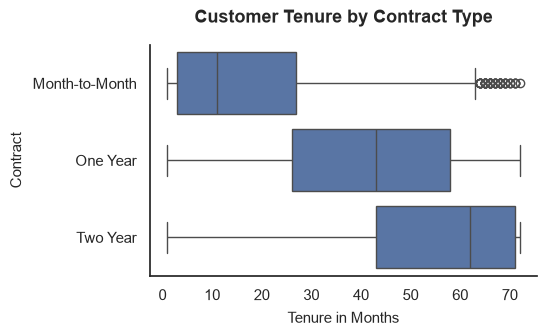

In [4]:
ax = sns.boxplot(
    data=churn_df,
    y=churn_df['Contract'],
    x=churn_df['Tenure in Months']
)

ax.set_title('Customer Tenure by Contract Type');

Median customer tenure increases across contract types, from approximately 11 months for month-to-month customers to 43 months for one-year customers and 62 months for two-year customers. The middle 50% of customers also shifts toward higher tenure as contract length increases. Despite this overall pattern, a small number of month-to-month customers have maintained their subscriptions for more than 60 months.  

#### Contract and Average Monthly Revenue
Do customers on different contract types generate different amounts of average monthly revenue?

Text(0.5, 0, 'Avg Monthly Revenue')

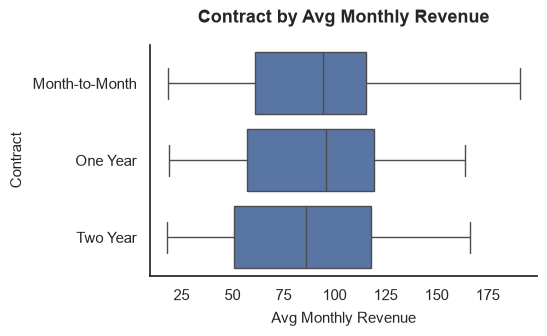

In [ ]:
ax = sns.boxplot(
    x=avg_monthly_revenue,
    y=churn_df['Contract']
)

ax.set_title('Contract by Avg Monthly Revenue')
ax.set_xlabel('Avg Monthly Revenue');

Average monthly revenue is relatively similar across contract types, with substantial overlap in their distributions. Month-to-month and one-year customers have median monthly revenues of approximately $95, while two-year customers have a slightly lower median of around $85. Overall, contract type does not appear to strongly differentiate customers based on average monthly revenue.  

### Service Usage and Billing



##### Core Services and Monthly Charges

- Do customers with phone service have higher monthly charges?
- Do customers with internet service have higher monthly charges?
- Do customers with multiple lines have higher monthly charges?

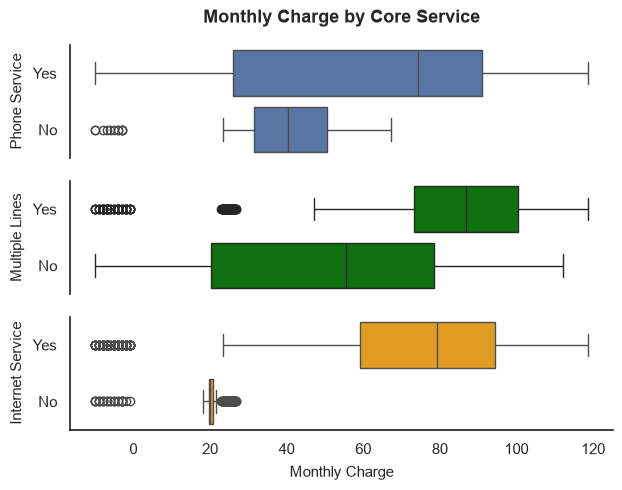

In [ ]:
phone_customers = churn_df[churn_df['Phone Service']]
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 5), sharex=True, sharey=True)

ax1 = sns.boxplot(
    data=churn_df,
    x='Monthly Charge',
    y=churn_df['Phone Service'].map({True: 'Yes', False: 'No'}),
    ax=ax1
)


ax2 = sns.boxplot(
    phone_customers,
    x='Monthly Charge',
    y=phone_customers['Multiple Lines'].map({True: 'Yes', False: 'No'}),
    ax=ax2,
    color='green'
)

ax3 = sns.boxplot(
    churn_df,
    x='Monthly Charge',
    y=churn_df['Internet Service'].map({True: 'Yes', False: 'No'}),
    ax=ax3,
    color='orange'
)

ax1.set_title('Monthly Charge by Core Service')
ax1.spines['bottom'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(hspace=0.2);



**Phone Service**
- Customers with phone service generally have higher monthly charges than those without phone service.
- Monthly charges among phone service customers also show a much wider range.

**Multiple Lines**
- Among customers with phone service, those with multiple lines tend to have higher monthly charges than those with a single line.
- Customers with multiple lines have a median monthly charge of approximately $85, compared with roughly $55 for those without multiple lines.

**Internet Service**
- Customers with internet service have substantially higher monthly charges than those without internet service.
- Customers without internet service are heavily concentrated around $20 per month, showing the clearest difference among the three core services.

##### Internet Type and Monthly Charge
Do monthly charges differ across internet types?

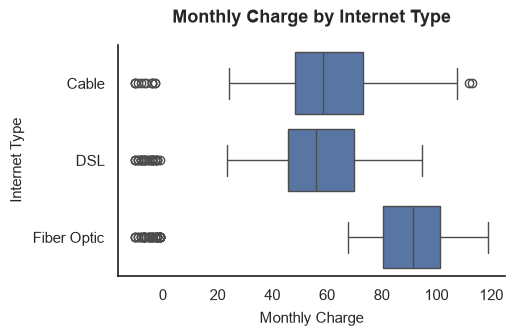

In [5]:
internet_customers = churn_df[churn_df['Internet Service']].copy()

internet_customers['Internet Type'] = (
    internet_customers['Internet Type'].cat.remove_unused_categories()
)

sns.boxplot(
    data=internet_customers,
    x='Monthly Charge',
    y='Internet Type'
)

plt.title('Monthly Charge by Internet Type');

Fiber Optic customers have the highest monthly charges, with a median of approximately $90, while Cable and DSL customers have lower and relatively similar median charges of around $55–60. Fiber Optic charges are also more concentrated at the higher end of the monthly charge range, while Cable and DSL show greater overlap. Overall, Fiber Optic service is associated with noticeably higher monthly charges compared with Cable and DSL.

##### Data Usage and Billing
Is higher monthly data usage associated with higher monthly charges?

Pearson Correlation: 0.37277602223924167


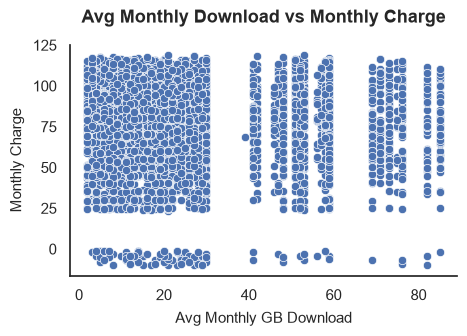

In [68]:
sns.scatterplot(
    internet_customers,
    x='Avg Monthly GB Download',
    y='Monthly Charge'
)

plt.title('Avg Monthly Download vs Monthly Charge')
print('Pearson Correlation:', churn_df['Avg Monthly GB Download'].corr(churn_df['Monthly Charge']))

Average monthly data usage and monthly charges have a weak-to-moderate positive correlation (r = 0.37), suggesting that customers who download more data tend to have somewhat higher monthly charges. However, monthly charges vary widely across nearly all levels of data usage, indicating that data usage alone does not closely correspond with how much customers pay per month.  

### Offers and Customer Behavior


##### Offers and Customer Behavior
- Does customer tenure differ across offers?
- Do monthly charges differ across offers?

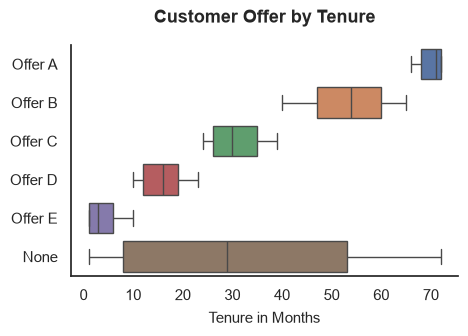

In [74]:
sns.boxplot(
    churn_df,
    x='Tenure in Months',
    y='Offer',
    hue='Offer',
    dodge=False
)
plt.title('Customer Offer by Tenure')
plt.ylabel('');

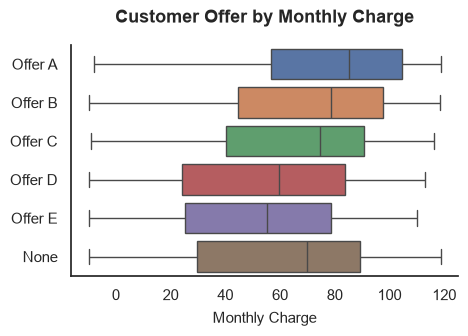

In [81]:
sns.boxplot(
    churn_df,
    x='Monthly Charge',
    y='Offer',
    hue='Offer',
    dodge=False
)
plt.title('Customer Offer by Monthly Charge')
plt.ylabel('');

Customer tenure differs substantially across offers, with Offer E concentrated among newer customers and Offer A among the longest-tenured customers. This suggests that offer assignment may be closely associated with customer tenure. Monthly charges also tend to be higher for Offers A and B and lower for Offers D and E, although the charge distributions overlap considerably across offers.


### Customer Churn Analysis

##### Customer Profile and Churn
- Does churn rate differ across age groups?

In [7]:
age_bins = list(range(19, 80, 5))
age_labels = []

for age in age_bins:
    age_labels.append(f'{age}-{age+4}')

age_labels[-1] = '79-80'
age_bins.append(81)

churn_df['Age Group'] = pd.cut(
    churn_df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

churned_by_age = (
    churn_df[churn_df['Customer Status'] == 'Churned']
    ['Age Group']
    .value_counts()
    .sort_index()
)

total_by_age = churn_df['Age Group'].value_counts().sort_index()
churn_rate_by_age = churned_by_age / total_by_age * 100

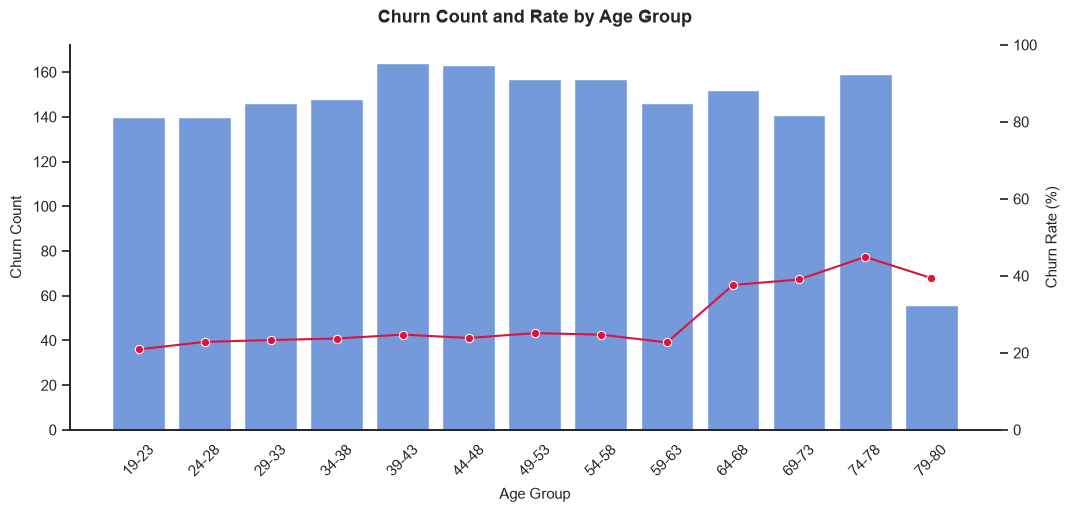

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Churn count
sns.barplot(
    x=churned_by_age.index,
    y=churned_by_age.values,
    ax=ax1,
    color='cornflowerblue'
)

ax1.set_xlabel('Age Group')
ax1.set_ylabel('Churn Count')

# Second y-axis
ax2 = ax1.twinx()

# Churn rate (pct)
sns.lineplot(
    x=churn_rate_by_age.index,
    y=churn_rate_by_age.values,
    marker='o',
    ax=ax2,
    color='crimson'
)

ax2.set_ylabel('Churn Rate (%)')
ax2.set_ylim(0, 100)

plt.title('Churn Count and Rate by Age Group')
ax1.tick_params(axis='x', rotation=45);

Churn counts remain relatively consistent across most age groups from 19–78, generally ranging from about 140 to 165 customers. However, the churn rate tells a different story: it remains around 20–25% through ages 19–63 before rising sharply to approximately 37–45% among customers aged 64–78. This indicates that while older age groups do not necessarily account for substantially more churn cases in absolute numbers, a much larger proportion of their customers churn. The 79–80 group has considerably fewer churn cases due to its smaller age range, but its churn rate remains high at approximately 40%.  

##### Tenure and Churn
- How does churn rate vary with customer tenure?

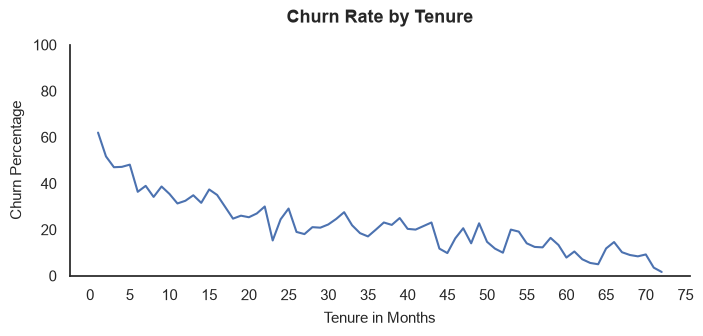

In [9]:
churned_customers = churn_df[churn_df['Customer Status'] == 'Churned']
total_by_tenure = churn_df['Tenure in Months'].value_counts().sort_index()
churn_rate_by_tenure = churned_customers.groupby('Tenure in Months')['Customer Status'].count() / total_by_tenure * 100
churn_rate_by_tenure

plt.figure(figsize=(8, 3))
sns.lineplot(
    x=churn_rate_by_tenure.index,
    y=churn_rate_by_tenure.values
)

plt.title('Churn Rate by Tenure')
plt.ylim(0, 100)
plt.ylabel('Churn Percentage')
plt.xticks(range(0, 76, 5));

Churn rate is highest among newly acquired customers, starting at approximately 60%, and generally declines as customer tenure increases. This suggests that customers are more likely to churn during the early stages of their relationship with the company, while longer-tenured customers tend to have lower churn rates.

**This suggests that customer retention efforts may be particularly valuable during the first few months of a customer's tenure, such as targeted onboarding, early-tenure offers, or other retention initiatives.**

##### Services and Churn
- Does churn rate differ across internet types?
- Does churn rate differ based on subscription to services?

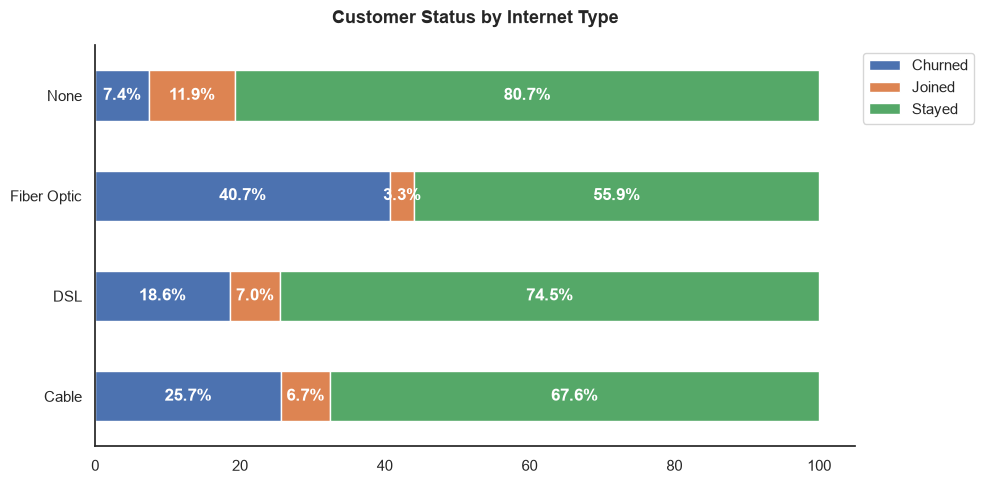

In [108]:
status_by_internet = pd.crosstab(
    churn_df['Internet Type'],
    churn_df['Customer Status'],
    normalize='index'
) * 100

ax = status_by_internet.plot.barh(
    stacked=True,
    figsize=(10, 5)
)

plt.title('Customer Status by Internet Type')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1, 1)
)

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.1f%%',
        label_type='center',
        fontsize=12,
        fontweight='bold',
        color='white'
    )

    plt.tight_layout();

Customer status varies noticeably across internet types. Fiber Optic stands out with a much larger share of churned customers and a smaller share of stayed customers compared with the other internet types. In contrast, customers without internet service show the opposite pattern, with the highest proportion staying and the lowest proportion churning.  This suggests that internet type, particularly Fiber Optic service, may be associated with customer churn and warrants further investigation.  

In [113]:
fiber_optic_churned = churn_df[
    (churn_df['Internet Type'] == 'Fiber Optic') &
    (churn_df['Customer Status'] == 'Churned')
]

fiber_optic_churned['Churn Category'].value_counts(normalize=True) * 100

Churn Category
Competitor         47.491909
Dissatisfaction    16.747573
Attitude           16.100324
Price              10.194175
Other               9.466019
Name: proportion, dtype: float64

Among Fiber Optic customers who churned, Competitor is the leading churn category at 46.5%, accounting for nearly half of churn cases. Dissatisfaction and Attitude follow at approximately 16% each, suggesting that Fiber Optic churn is more commonly associated with competitive alternatives than with price or other factors.  

What competitor-related reasons are driving Fiber Optic customers to churn?

In [115]:
fiber_optic_churned_comp = fiber_optic_churned[
    fiber_optic_churned['Churn Category'] == 'Competitor'
]

fiber_optic_churned_comp['Churn Reason'].cat.remove_unused_categories().value_counts(normalize=True) * 100

Churn Reason
Competitor had better devices                37.308348
Competitor made better offer                 37.308348
Competitor offered more data                 14.821124
Competitor offered higher download speeds    10.562181
Name: proportion, dtype: float64

Among Fiber Optic customers who churned due to a competitor, better devices and better offers are the leading reasons, each accounting for 37.3% of cases. Together, they represent nearly three-quarters of competitor-related churn, while more data and higher download speeds account for smaller shares. This suggests that Fiber Optic churn is more associated with competitors' devices and offers than with internet performance itself.  

##### Contracts, Offers, and Churn
- Does churn rate differ across contract types?
- Does churn rate differ across offer types?

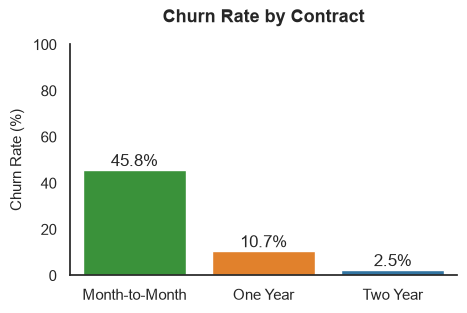

In [ ]:
churn_rate_by_contract = (churned_customers.groupby('Contract')['Customer Status'].count() 
                          / churn_df['Contract'].value_counts() * 100)

ax = sns.barplot(
    x=churn_rate_by_contract.index,
    y=churn_rate_by_contract.values,
    hue=churn_rate_by_contract.values,
    dodge=False,
    palette='tab10',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.title('Churn Rate by Contract')
plt.ylabel('Churn Rate (%)')
plt.xlabel('')
plt.ylim(top=100);

Nearly half of month-to-month customers have churned, with a churn rate of 45.8%. In comparison, churn rates are substantially lower among customers with one-year contracts (10.7%) and two-year contracts (2.5%).

**This shows a clear association between longer contract terms and lower churn rates, with month-to-month customers representing a much higher-churn segment.**

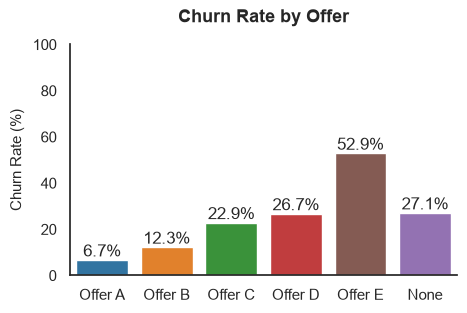

In [30]:
churn_rate_by_offer = (churned_customers.groupby('Offer')['Customer Status'].count() 
                          / churn_df['Offer'].value_counts() * 100)

ax = sns.barplot(
    x=churn_rate_by_offer.index,
    y=churn_rate_by_offer.values,
    hue=churn_rate_by_offer.values,
    dodge=False,
    palette='tab10',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.title('Churn Rate by Offer')
plt.ylabel('Churn Rate (%)')
plt.xlabel('')
plt.ylim(top=100);

Churn rates vary considerably across offers. Offer E has the highest churn rate at 52.9%, while Offer A has the lowest at 6.7%. This pattern aligns with the earlier tenure analysis, where Offer E was concentrated among newer customers and Offer A among longer-tenured customers. Since churn was also found to be highest during the early months of customer tenure and to decline as tenure increases, the differences in churn across offers may partly reflect the tenure profiles of customers receiving each offer rather than the effect of the offers themselves.  

##### Billing and Churn
- Does churn rate differ across payment methods?
- Does churn rate differ across monthly charge levels?


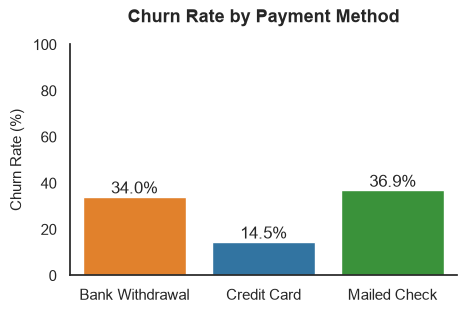

In [32]:
churn_rate_by_payment = (churned_customers.groupby('Payment Method')['Customer Status'].count() 
                          / churn_df['Payment Method'].value_counts() * 100)

ax = sns.barplot(
    x=churn_rate_by_payment.index,
    y=churn_rate_by_payment.values,
    hue=churn_rate_by_payment.values,
    dodge=False,
    palette='tab10',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xlabel('')
plt.ylim(top=100);

Credit Card customers showinshow considerably lower churn than customers using the other payment methods.  

In [33]:
churn_df['Monthly Charge'].describe()

count    7043.000000
mean       63.596134
std        31.204744
min       -10.000000
25%        30.400000
50%        70.050003
75%        89.750000
max       118.750000
Name: Monthly Charge, dtype: float64

(0.0, 100.0)

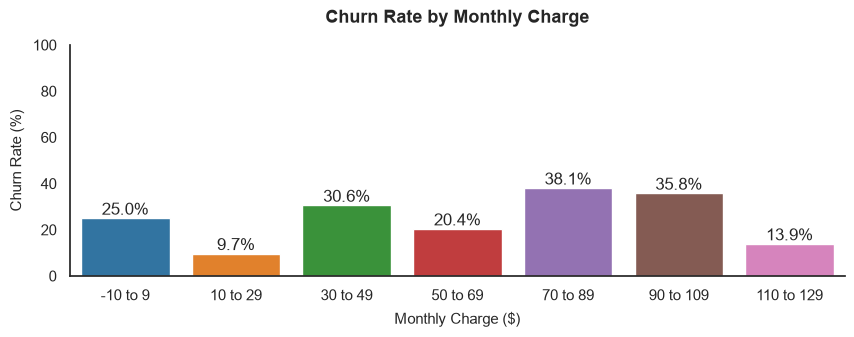

In [61]:
charge_bins = list(range(-10, 131, 20))
 
charge_labels = [f'{charge} to {charge+19}' for charge in charge_bins[:-1]]

churn_df['Charge Level'] = pd.cut(
    churn_df['Monthly Charge'],
    bins=charge_bins,
    labels=charge_labels,
    right=False
)

churn_rate_by_charge = churn_df.groupby('Charge Level')['Customer Status'].value_counts(normalize=True).loc[:, 'Churned'] * 100

plt.figure(figsize=(10, 3))
ax = sns.barplot(
    x=churn_rate_by_charge.index,
    y=churn_rate_by_charge.values,
    hue=churn_rate_by_charge.index,
    dodge=False,
    palette='tab10'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%'
    )

plt.title('Churn Rate by Monthly Charge')
plt.xlabel('Monthly Charge ($)')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)



Churn rate varies across monthly charge levels but does not increase consistently as monthly charges rise. Customers paying $70–89 have the highest churn rate at 38.1%, followed by those paying $90–109 at 35.8%. However, churn drops substantially to 13.9% among customers paying $110–129. Lower charge levels also show considerable variation, ranging from 9.7% to 30.6%. 

**Overall, monthly charge alone does not show a clear linear relationship with churn.**